In [1]:
# Neural Network Training for Flight Delay Prediction
# This notebook trains a PyTorch model on GPU and exports to ONNX

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import pickle
import time
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*60)
print("TRAINING ENVIRONMENT")
print("="*60)
print(f"Device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print("⚡ GPU acceleration enabled!")
else:
    print("📊 Running on CPU (training will be slower)")

print(f"PyTorch Version: {torch.__version__}")
print("="*60)

TRAINING ENVIRONMENT
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Memory: 8.0 GB
CUDA Version: 12.9
⚡ GPU acceleration enabled!
PyTorch Version: 2.8.0+cu129


In [2]:
# Load the processed datasets from notebook 02

print("Loading processed datasets...")

X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✓ Data loaded!")
print(f"\nDataset sizes:")
print(f"  Training:   {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"  Validation: {X_val.shape[0]:,} samples × {X_val.shape[1]} features")
print(f"  Test:       {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

print(f"\nClass distribution:")
print(f"  Train - Delayed: {y_train.mean()*100:.1f}%")
print(f"  Val   - Delayed: {y_val.mean()*100:.1f}%")
print(f"  Test  - Delayed: {y_test.mean()*100:.1f}%")

print(f"\nFeature names:")
print(X_train.columns.tolist())

Loading processed datasets...
✓ Data loaded!

Dataset sizes:
  Training:   4,189,659 samples × 31 features
  Validation: 1,396,553 samples × 31 features
  Test:       1,396,554 samples × 31 features

Class distribution:
  Train - Delayed: 20.0%
  Val   - Delayed: 20.0%
  Test  - Delayed: 20.0%

Feature names:
['month', 'day_of_month', 'day_of_week', 'dep_hour', 'dep_minute', 'arr_hour', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'is_morning_rush', 'is_evening_rush', 'is_weekend', 'is_holiday_season', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'origin_encoded', 'dest_encoded', 'distance', 'carrier_encoded', 'origin_delay_rate', 'dest_delay_rate', 'carrier_delay_rate', 'route_delay_rate', 'origin_daily_flights', 'dest_daily_flights', 'crs_elapsed_time']


In [3]:
# Convert pandas DataFrames to PyTorch tensors

print("Converting to PyTorch tensors...")

# Convert to numpy arrays first
X_train_np = X_train.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

y_train_np = y_train.astype(np.float32)
y_val_np = y_val.astype(np.float32)
y_test_np = y_test.astype(np.float32)

# Create PyTorch tensors and move to device
X_train_tensor = torch.FloatTensor(X_train_np).to(device)
y_train_tensor = torch.FloatTensor(y_train_np).to(device)

X_val_tensor = torch.FloatTensor(X_val_np).to(device)
y_val_tensor = torch.FloatTensor(y_val_np).to(device)

X_test_tensor = torch.FloatTensor(X_test_np).to(device)
y_test_tensor = torch.FloatTensor(y_test_np).to(device)

print("✓ Tensors created and moved to device!")
print(f"\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  y_train: {y_train_tensor.shape}")

# Create DataLoaders for batch processing
batch_size = 1024  # Large batch size for GPU efficiency

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

Converting to PyTorch tensors...
✓ Tensors created and moved to device!

Tensor shapes:
  X_train: torch.Size([4189659, 31])
  y_train: torch.Size([4189659])

DataLoaders created with batch size: 1024
  Training batches: 4092
  Validation batches: 1364


In [4]:
# Define the neural network model

class FlightDelayPredictor(nn.Module):
    """
    Neural Network for Binary Classification of Flight Delays
    
    Architecture:
    - Input: 31 features
    - Hidden Layer 1: 128 neurons + ReLU + Dropout(0.3)
    - Hidden Layer 2: 64 neurons + ReLU + Dropout(0.3)
    - Hidden Layer 3: 32 neurons + ReLU + Dropout(0.2)
    - Output: 1 neuron + Sigmoid (probability of delay)
    """
    
    def __init__(self, input_size=31):
        super(FlightDelayPredictor, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)  # Batch normalization for stability
        self.dropout1 = nn.Dropout(0.3)
        
        # Layer 2
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)
        
        # Layer 3
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)
        
        # Output layer
        self.fc4 = nn.Linear(32, 1)
        
        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        # Layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        # Output
        x = self.fc4(x)
        x = self.sigmoid(x)
        
        return x

# Create model instance
input_size = X_train.shape[1]
model = FlightDelayPredictor(input_size=input_size)
model = model.to(device)

print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)
print("="*60)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MODEL ARCHITECTURE
FlightDelayPredictor(
  (fc1): Linear(in_features=31, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Total parameters: 14,913
Trainable parameters: 14,913


In [5]:
# Loss function with class weighting to handle imbalance

# Calculate class weights (inverse of class frequency)
# We have ~80% on-time, ~20% delayed
# Weight delayed class higher so model pays more attention to it

class_counts = np.bincount(y_train.astype(int))
total_samples = len(y_train)

weight_for_0 = total_samples / (2 * class_counts[0])  # On-time
weight_for_1 = total_samples / (2 * class_counts[1])  # Delayed

print("="*60)
print("⚖️  CLASS WEIGHTING")
print("="*60)
print(f"Class 0 (On-time): {class_counts[0]:,} samples")
print(f"Class 1 (Delayed): {class_counts[1]:,} samples")
print(f"\nClass weights:")
print(f"  Weight for class 0: {weight_for_0:.3f}")
print(f"  Weight for class 1: {weight_for_1:.3f}")
print("="*60)

# Create weighted loss function
class_weights = torch.FloatTensor([weight_for_1]).to(device)
criterion = nn.BCELoss(weight=None)  # We'll apply weights manually in training loop

# Optimizer: Adam (adaptive learning rate)
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,      # Reduce LR by half
    patience=3      # After 3 epochs with no improvement
)

print(f"\n🎯 Optimizer: Adam")
print(f"📊 Initial Learning Rate: {learning_rate}")
print(f"📉 LR Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

⚖️  CLASS WEIGHTING
Class 0 (On-time): 3,352,594 samples
Class 1 (Delayed): 837,065 samples

Class weights:
  Weight for class 0: 0.625
  Weight for class 1: 2.503

🎯 Optimizer: Adam
📊 Initial Learning Rate: 0.001
📉 LR Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


In [6]:
# Training loop with validation and early stopping

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_predictions.extend(outputs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * correct / total
    
    # Calculate additional metrics
    predictions_binary = (np.array(all_predictions) > 0.5).astype(int)
    f1 = f1_score(all_targets, predictions_binary)
    roc_auc = roc_auc_score(all_targets, all_predictions)
    
    return epoch_loss, epoch_acc, f1, roc_auc

# Training configuration
num_epochs = 20
best_val_loss = float('inf')
best_model_state = None
patience = 5
patience_counter = 0

# Storage for metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_roc_auc': []
}

print("="*60)
print("🏋️  TRAINING START")
print("="*60)
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Early stopping patience: {patience}")
print("="*60)

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, val_roc_auc = validate(model, val_loader, criterion, device)
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_roc_auc'].append(val_roc_auc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        best_epoch = epoch + 1
    else:
        patience_counter += 1
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.1f}s)")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Val F1:     {val_f1:.4f} | Val ROC-AUC: {val_roc_auc:.4f}")
    
    if patience_counter == 0:
        print(f"  ⭐ Best model so far!")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"  Best epoch was {best_epoch} with val_loss={best_val_loss:.4f}")
        break
    
    print("-" * 60)

total_time = time.time() - start_time

print("="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total training time: {total_time/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best epoch: {best_epoch}")
print("="*60)

# Load best model
model.load_state_dict(best_model_state)
print("✓ Best model weights loaded")

🏋️  TRAINING START
Epochs: 20
Batch size: 1024
Early stopping patience: 5
Epoch [1/20] (37.9s)
  Train Loss: 0.4704 | Train Acc: 79.70%
  Val Loss:   0.4579 | Val Acc:   80.15%
  Val F1:     0.0420 | Val ROC-AUC: 0.7025
  ⭐ Best model so far!
------------------------------------------------------------
Epoch [2/20] (37.8s)
  Train Loss: 0.4596 | Train Acc: 80.17%
  Val Loss:   0.4547 | Val Acc:   80.31%
  Val F1:     0.0854 | Val ROC-AUC: 0.7089
  ⭐ Best model so far!
------------------------------------------------------------
Epoch [3/20] (36.1s)
  Train Loss: 0.4571 | Train Acc: 80.24%
  Val Loss:   0.4525 | Val Acc:   80.45%
  Val F1:     0.1156 | Val ROC-AUC: 0.7128
  ⭐ Best model so far!
------------------------------------------------------------
Epoch [4/20] (36.2s)
  Train Loss: 0.4558 | Train Acc: 80.30%
  Val Loss:   0.4514 | Val Acc:   80.49%
  Val F1:     0.1199 | Val ROC-AUC: 0.7148
  ⭐ Best model so far!
------------------------------------------------------------
Epoch 

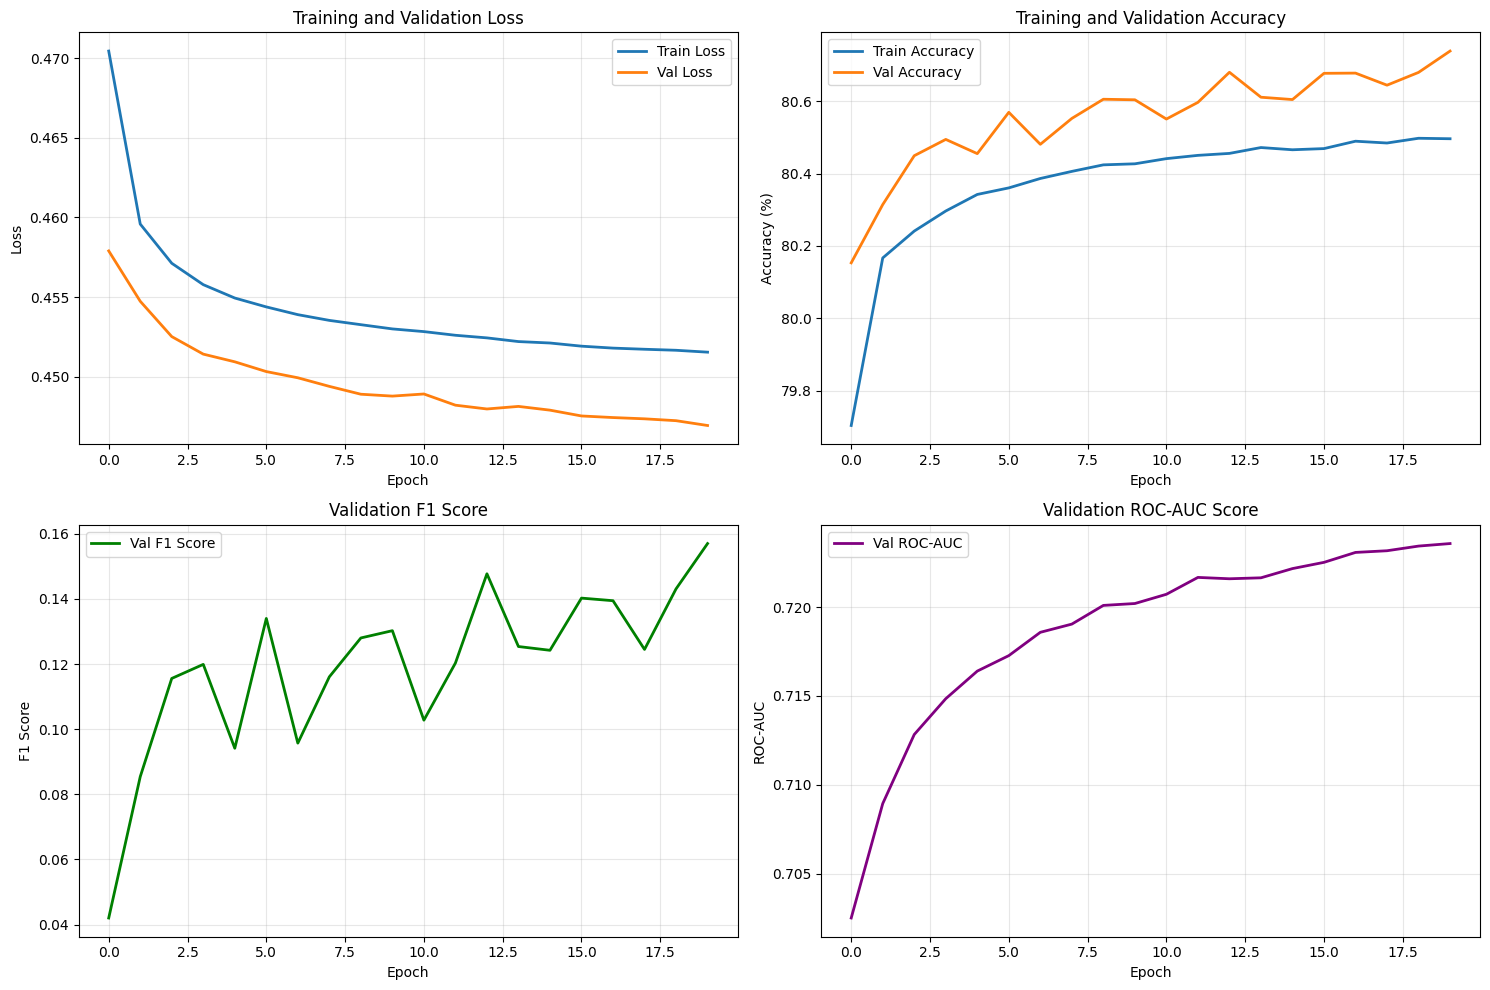

✓ Training history plot saved to ../data/models/training_history.png


In [7]:
# Plot training and validation metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: F1 Score
axes[1, 0].plot(history['val_f1'], label='Val F1 Score', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ROC-AUC
axes[1, 1].plot(history['val_roc_auc'], label='Val ROC-AUC', color='purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Validation ROC-AUC Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved to ../data/models/training_history.png")